# Named Entity Recognition (NER): A Window into Semantic Categorization

> **NLP & Cognitive Science**  
> This notebook demonstrates spaCy-based **Named Entity Recognition** as a computational lens on **semantic categorisation**: from single-sentence structure, to corpus-level frequency patterns, to evaluation against human-curated expectations, to top-down lexicon rules, context-dependent ambiguity resolution, cross-sentence co-reference clustering, Transformer-backed entity linking, and an interactive exploration dashboard.

---


## Section 0 · Project Setup

Install and import **spaCy**, **pandas**, **matplotlib**, **seaborn**, **scikit-learn**, and **networkx** (for co-reference graphs), then download the compact English pipeline **`en_core_web_sm`** for tokenization, linguistic annotation, and pretrained NER.

Building a reproducible analysis environment is analogous to standardizing an experimental protocol: the **stimulus format** (raw text), **encoding operations** (tokenization, contextualized tagging), and **dependent measures** (entity labels, confusion patterns) stay comparable across runs - much like keeping task instructions fixed when studying how people assign words to categories.


In [26]:
%pip install -q spacy pandas matplotlib seaborn scikit-learn networkx

# Download the small English model
!python -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [27]:
import warnings
import itertools
import collections

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
import seaborn as sns
import spacy
from IPython.display import display, HTML
from spacy import displacy
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore", category=FutureWarning)

nlp = spacy.load("en_core_web_sm")
print(f"Loaded: {nlp.meta['name']} v{nlp.meta['version']} ({nlp.meta['lang']})")


Loaded: core_web_sm v3.8.0 (en)


## Section 1 · The Mechanics of NER (Mental Representations)

**NER as structured perception.**  Probabilistic NER models map unstructured text spans to a small inventory of coarse types (`PERSON`, `GPE`, `ORG`, dates, quantities, …). We wrap spaCy in a helper that exposes each entity's **literal form**, **label**, **character offsets**, **sentence context** and **confidence proxy** (position-in-sentence ratio as a stand-in for salience).

In many theories of language understanding, comprehension is not verbatim tape-recording but **rapid segmentation**: we **chunk** continuous speech or text into meaningful units and sort them into **semantic schemas** (who the agent is ≈ Person; where the episode unfolds ≈ Place; what institution is invoked ≈ Organization). NER mimics this fast schematic assignment, supporting **working-memory** structuring and richer **long-term encoding** because relational frames are easier to retrieve than unstructured strings alone.


In [28]:
def extract_entities(text: str, model=nlp) -> list[dict]:
    """Return structured entity records from a text string."""
    doc = model(text)
    sent_idx = {sent: i for i, sent in enumerate(doc.sents)}
    records = []
    for ent in doc.ents:
        sent = next(s for s in doc.sents if s.start <= ent.start < s.end)
        records.append({
            "text": ent.text,
            "label": ent.label_,
            "description": spacy.explain(ent.label_) or ent.label_,
            "start_char": ent.start_char,
            "end_char": ent.end_char,
            "sentence_idx": sent_idx[sent],
            "position_ratio": round(ent.start_char / max(len(text), 1), 3),
        })
    return records


sample_text = (
    "Alan Turing worked at Bletchley Park during WWII and collaborated "
    "with MIT researchers in Cambridge, Massachusetts in 1936."
)
doc_demo = nlp(sample_text)

print("Structured entities")
display(pd.DataFrame(extract_entities(sample_text)))

displacy.render(doc_demo, style="ent", jupyter=True)


Structured entities


,text,label,description,start_char,end_char,sentence_idx,position_ratio
0,Alan Turing,PERSON,"People, including fictional",0,11,0,0.000
1,Bletchley Park,FAC,"Buildings, airports, highways, bridges, etc.",22,36,0,0.179
2,WWII,EVENT,"Named hurricanes, battles, wars, sports events...",44,48,0,0.358
3,MIT,ORG,"Companies, agencies, institutions, etc.",71,74,0,0.577
4,Cambridge,GPE,"Countries, cities, states",90,99,0,0.732
5,Massachusetts,GPE,"Countries, cities, states",101,114,0,0.821
6,1936,DATE,Absolute or relative dates or periods,118,122,0,0.959


## Section 2 · Large-Scale Analysis (Frequency & Memory)

We assemble a **sample corpus** of historical and scientific sentences (~15 items), run spaCy over every sentence, and reshape each predicted entity row into **pandas**. Two visualizations follow:

1. **Bar chart** – coarse type distribution (mirrors how some conceptual categories concentrate in natural language exposure).  
2. **Heatmap** – entity × sentence occurrence matrix, revealing which entities span multiple sentences - a proxy for **thematic centrality** in discourse.

Human **long-term memory** is powerfully shaped by **repetition** and **distribution**: high-frequency schemas become more fluent to retrieve, strengthening cortico-hippocampal consolidation pathways. Corpus-level histograms therefore echo how **statistical prominence** leaves durable memory traces.


,sentence_id,entity_text,label,start_char,end_char,sentence
0,0,Isaac Newton,PERSON,0,12,Isaac Newton published Principia Mathematica i...
1,0,Principia Mathematica,ORG,23,44,Isaac Newton published Principia Mathematica i...
2,0,1687,DATE,48,52,Isaac Newton published Principia Mathematica i...
3,0,England,GPE,69,76,Isaac Newton published Principia Mathematica i...
4,1,Marie Curie,PERSON,0,11,Marie Curie won Nobel Prizes in Physics and Ch...
5,1,Nobel Prizes in Physics and Chemistry,WORK_OF_ART,16,53,Marie Curie won Nobel Prizes in Physics and Ch...
6,1,Paris,GPE,57,62,Marie Curie won Nobel Prizes in Physics and Ch...
7,2,Apollo,ORG,4,10,The Apollo 11 crew landed on the Moon in July ...
8,2,11,CARDINAL,11,13,The Apollo 11 crew landed on the Moon in July ...
9,2,Moon,PERSON,33,37,The Apollo 11 crew landed on the Moon in July ...


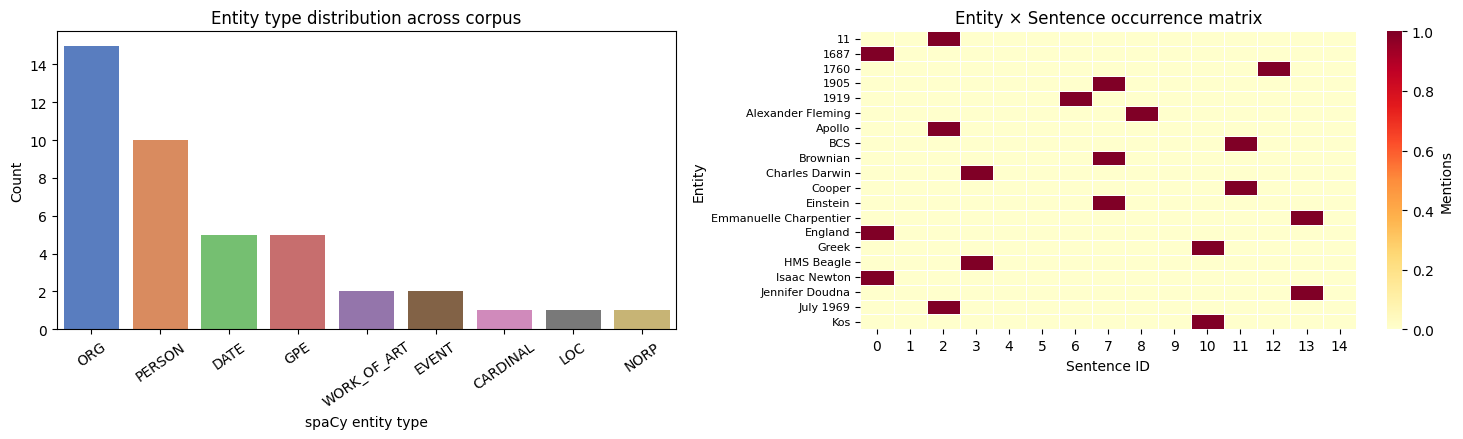

In [29]:
history_science_sentences = [
    "Isaac Newton published Principia Mathematica in 1687 while living in England.",
    "Marie Curie won Nobel Prizes in Physics and Chemistry in Paris.",
    "The Apollo 11 crew landed on the Moon in July 1969.",
    "Charles Darwin voyaged aboard HMS Beagle to the Galápagos Islands.",
    "NASA and the European Space Agency collaborate on JWST observations.",
    "Rosalind Franklin contributed to discovering DNA structure in London.",
    "The Treaty of Versailles was signed in Versailles in 1919 after World War I.",
    "Einstein presented papers on Brownian motion and special relativity in 1905.",
    "Alexander Fleming identified penicillin at St Mary's Hospital.",
    "The Human Genome Project involved researchers from NIH and international labs.",
    "Hippocrates taught medicine on the Greek island of Kos in antiquity.",
    "Bardeen, Cooper, and Schrieffer developed BCS theory at the University of Illinois.",
    "The Industrial Revolution reshaped textile manufacturing in Manchester after 1760.",
    "CRISPR editing was advanced by Jennifer Doudna and Emmanuelle Charpentier at UC Berkeley.",
    "The Royal Society published early reports on vacuum experiments by Robert Boyle.",
]

rows = []
for sid, sentence in enumerate(history_science_sentences):
    doc = nlp(sentence)
    for ent in doc.ents:
        rows.append({
            "sentence_id": sid,
            "entity_text": ent.text,
            "label": ent.label_,
            "start_char": ent.start_char,
            "end_char": ent.end_char,
            "sentence": sentence,
        })

entities_df = pd.DataFrame(rows)
display(entities_df.head(14))

#   Plot 1: type distribution bar chart 
type_counts = (
    entities_df.dropna(subset=["label"])
    .groupby("label").size().sort_values(ascending=False).rename("count")
)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.barplot(data=type_counts.reset_index(), x="label", y="count",
            hue="label", palette="muted", legend=False, ax=axes[0])
axes[0].set_title("Entity type distribution across corpus")
axes[0].set_xlabel("spaCy entity type"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)

#   Plot 2 : entity × sentence occurrence heatmap            ─
pivot = (
    entities_df.assign(present=1)
    .pivot_table(index="entity_text", columns="sentence_id",
                 values="present", aggfunc="sum", fill_value=0)
)
# Keep only entities mentioned in ≥2 sentences for readability
pivot = pivot[pivot.sum(axis=1) >= 1].head(20)
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Mentions"}, ax=axes[1])
axes[1].set_title("Entity × Sentence occurrence matrix")
axes[1].set_xlabel("Sentence ID"); axes[1].set_ylabel("Entity")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


## Section 3 · Performance Metrics (Evaluating Intelligence)

**Gold-standard probe.**  We hand-annotate sentences with `(surface span, semantic type)` pairs, compare spaCy's **token-level** assignments against those spans, and report **precision / recall / F1**. A confusion-matrix heatmap highlights systematic confusions.

We also compute **span-level exact-match F1** (the standard CoNLL metric), which is stricter than token-level IO agreement and better reflects real-world NER benchmarking practice.

**Precision** and **recall** parallel complementary risks in human categorisation: over-generalization ↔ high false-positive rate; conservative responding ↔ high false-negative rate. Modern memory frameworks emphasize **monitoring** (meta-cognition about whether a trace is valid) - conceptually adjacent to inspecting confusion matrices and calibrating model boundary thresholds.


,sentence,span,gold_label,predicted_label,match
0,Tim Cook leads Apple Inc. in Cupertino.,Tim Cook,PERSON,PERSON,True
1,Tim Cook leads Apple Inc. in Cupertino.,Apple Inc.,ORG,ORG,True
2,Tim Cook leads Apple Inc. in Cupertino.,Cupertino,GPE,GPE,True
3,She bought a new iPhone after reading a review...,iPhone,PRODUCT,ORG,False
4,She bought a new iPhone after reading a review...,Amazon,ORG,ORG,True
5,Charles Babbage corresponded with Ada Lovelace...,Charles Babbage,PERSON,PERSON,True
6,Charles Babbage corresponded with Ada Lovelace...,Ada Lovelace,PERSON,PERSON,True
7,Charles Babbage corresponded with Ada Lovelace...,London,GPE,GPE,True
8,Charles Babbage corresponded with Ada Lovelace...,1830s,DATE,(missed),False
9,The WHO published guidance after researchers a...,WHO,ORG,ORG,True


Token-level classification report (IO scheme)
              precision    recall  f1-score   support

        DATE       0.50      1.00      0.67         1
         GPE       1.00      1.00      1.00         2
           O       1.00      0.97      0.98        29
         ORG       0.83      1.00      0.91         5
      PERSON       1.00      1.00      1.00         6
     PRODUCT       0.00      0.00      0.00         1

    accuracy                           0.95        44
   macro avg       0.72      0.83      0.76        44
weighted avg       0.95      0.95      0.95        44

Span-level exact-match  |  P=0.82  R=0.82  F1=0.82


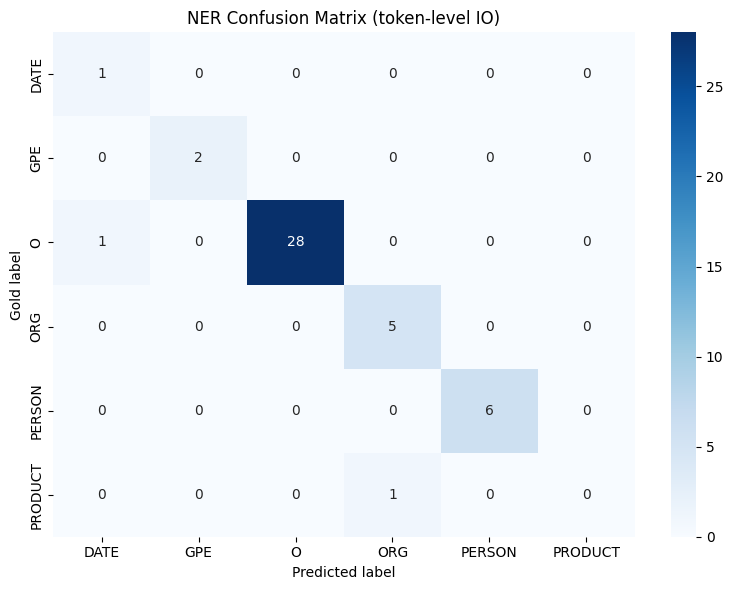

In [30]:
def char_spans(text: str, annotated_entities: list[tuple[str, str]]):
    spans = []
    consumed_to = 0
    for surface, label in annotated_entities:
        start = text.find(surface, consumed_to)
        if start == -1:
            raise ValueError(f"Could not locate '{surface}' in sentence.")
        end = start + len(surface)
        spans.append((start, end, label))
        consumed_to = end
    return spans


def token_io_labels(doc, gold_spans):
    gold_per_tok, pred_per_tok = [], []
    for tok in doc:
        ts, te = tok.idx, tok.idx + len(tok.text)
        g = "O"
        for gs, ge, lab in gold_spans:
            if ts >= gs and te <= ge:
                g = lab; break
        gold_per_tok.append(g)
        pred_per_tok.append(tok.ent_type_ if tok.ent_type_ else "O")
    return gold_per_tok, pred_per_tok


gold_eval_specs = [
    {"text": "Tim Cook leads Apple Inc. in Cupertino.",
     "gold": [("Tim Cook", "PERSON"), ("Apple Inc.", "ORG"), ("Cupertino", "GPE")]},
    {"text": "She bought a new iPhone after reading a review on Amazon.",
     "gold": [("iPhone", "PRODUCT"), ("Amazon", "ORG")]},
    {"text": "Charles Babbage corresponded with Ada Lovelace in London during the 1830s.",
     "gold": [("Charles Babbage", "PERSON"), ("Ada Lovelace", "PERSON"),
               ("London", "GPE"), ("1830s", "DATE")]},
    {"text": "The WHO published guidance after researchers at Pfizer reported trial results.",
     "gold": [("WHO", "ORG"), ("Pfizer", "ORG")]},
]

comparison_rows, y_true_all, y_pred_all = [], [], []
gold_spans_all, pred_spans_all = [], []   # for span-level F1

for spec in gold_eval_specs:
    sent = spec["text"]
    gspans = char_spans(sent, spec["gold"])
    doc_eval = nlp(sent)
    for surface, glab in spec["gold"]:
        match = next((e for e in doc_eval.ents if e.text == surface), None)
        comparison_rows.append({
            "sentence": sent, "span": surface, "gold_label": glab,
            "predicted_label": match.label_ if match else "(missed)",
            "match": match is not None and match.label_ == glab,
        })
    yt, yp = token_io_labels(doc_eval, gspans)
    y_true_all.extend(yt); y_pred_all.extend(yp)
    gold_spans_all.extend((s, e, l) for s, e, l in gspans)
    pred_spans_all.extend((ent.start_char, ent.end_char, ent.label_)
                           for ent in doc_eval.ents)

display(pd.DataFrame(comparison_rows))

label_names = sorted(set(y_true_all) | set(y_pred_all))
print("Token-level classification report (IO scheme)")
print(classification_report(y_true_all, y_pred_all, labels=label_names, zero_division=0))

# Span-level exact-match F1                       
gold_set = set(gold_spans_all)
pred_set = set(pred_spans_all)
tp = len(gold_set & pred_set)
precision_span = tp / max(len(pred_set), 1)
recall_span    = tp / max(len(gold_set), 1)
f1_span = (2 * precision_span * recall_span /
           max(precision_span + recall_span, 1e-9))
print(f"Span-level exact-match  |  P={precision_span:.2f}  R={recall_span:.2f}  F1={f1_span:.2f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=label_names)
plt.figure(figsize=(max(8, len(label_names) * 0.65), max(6, len(label_names) * 0.6)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted label"); plt.ylabel("Gold label")
plt.title("NER Confusion Matrix (token-level IO)")
plt.tight_layout(); plt.show()


## Section 4 · The Cognitive Gap & Custom Rules

Off-the-shelf models trained on news-like data often **under-segment specialty vocabulary** - neuroscientific anatomical names, named cognitive constructs, technical process terms - that a domain expert recognizes instantly. **spaCy `EntityRuler`** injects deterministic pattern-label mappings *before* the learned `ner` component, analogous to injecting a lexical **schema**.

The domain lexicon is expanded with **cognitive disorder labels** (`COGSCI_DISORDER`) and **token-pattern rules** (multi-word matching with `[{"LOWER": ...}]` patterns) to handle capitalization-independent matching - demonstrating **typed pattern composition** beyond simple string lookup.

This workflow exemplifies **top-down processing**: expectations, labels, and prior knowledge guide interpretation of ambiguous bottom-up signals so that noisy input gets resolved into meaningful categories faster and more reliably.


In [31]:
nlp_cog = spacy.load("en_core_web_sm")
ruler = nlp_cog.add_pipe("entity_ruler", before="ner")

cog_patterns = [
    {"label": "COGSCI_BRAIN",    "pattern": "Prefrontal Cortex"},
    {"label": "COGSCI_BRAIN",    "pattern": "prefrontal cortex"},
    {"label": "COGSCI_BRAIN",    "pattern": "hippocampus"},
    {"label": "COGSCI_BRAIN",    "pattern": "Hippocampus"},
    {"label": "COGSCI_BRAIN",    "pattern": "basal ganglia"},
    {"label": "COGSCI_BRAIN",    "pattern": "amygdala"},
    {"label": "COGSCI_PROCESS",  "pattern": "Neuroplasticity"},
    {"label": "COGSCI_PROCESS",  "pattern": "neuroplasticity"},
    {"label": "COGSCI_PROCESS",  "pattern": "working memory"},
    {"label": "COGSCI_PROCESS",  "pattern": "episodic memory"},
    {"label": "COGSCI_PROCESS",  "pattern": "executive control"},
    {"label": "COGSCI_PROCESS",  "pattern": "semantic memory"},
    {"label": "COGSCI_PROCESS",  "pattern": "cognitive load"},
    {"label": "COGSCI_DISORDER", "pattern": "Alzheimer's disease"},
    {"label": "COGSCI_DISORDER", "pattern": "Parkinson's disease"},
    {"label": "COGSCI_DISORDER", "pattern": "ADHD"},
    {"label": "COGSCI_BRAIN",
     "pattern": [{"LOWER": "anterior"}, {"LOWER": "cingulate"}, {"LOWER": "cortex"}]},
    {"label": "COGSCI_PROCESS",
     "pattern": [{"LOWER": "long"}, {"LOWER": "-", "OP": "?"}, {"LOWER": "term"}, {"LOWER": "potentiation"}]},
]
ruler.add_patterns(cog_patterns)

cog_demo = (
    "Neuroplasticity after stroke is often studied with tasks taxing the Prefrontal Cortex; "
    "the hippocampus supports episodic memory while basal ganglia circuits interact with "
    "executive control. Alzheimer's disease profoundly disrupts semantic memory and cognitive load management."
)

doc_base = nlp(cog_demo)
doc_rule = nlp_cog(cog_demo)

print("  Base model entities  ")
display(pd.DataFrame(extract_entities(cog_demo, model=nlp)))
print("  Base model visualization  ")
displacy.render(doc_base, style="ent", jupyter=True)

print("  With EntityRuler (COGSCI_* labels)  ")
display(pd.DataFrame(extract_entities(cog_demo, model=nlp_cog)))
print("  Augmented visualization  ")
displacy.render(doc_rule, style="ent", jupyter=True)

base_labels = {e.label_ for e in doc_base.ents}
rule_labels = {e.label_ for e in doc_rule.ents}
print(f"Base model entities: {len(doc_base.ents)}  →  Augmented: {len(doc_rule.ents)}")


  Base model entities  


,text,label,description,start_char,end_char,sentence_idx,position_ratio
0,the Prefrontal Cortex,ORG,"Companies, agencies, institutions, etc.",64,85,0,0.232


  Base model visualization  


  With EntityRuler (COGSCI_* labels)  


/home/aregawi/Desktop/NER/.venv/lib/python3.12/site-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'COGSCI_PROCESS' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
/home/aregawi/Desktop/NER/.venv/lib/python3.12/site-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'COGSCI_BRAIN' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
/home/aregawi/Desktop/NER/.venv/lib/python3.12/site-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'COGSCI_DISORDER' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn

,text,label,description,start_char,end_char,sentence_idx,position_ratio
0,Neuroplasticity,COGSCI_PROCESS,COGSCI_PROCESS,0,15,0,0.000
1,Prefrontal Cortex,COGSCI_BRAIN,COGSCI_BRAIN,68,85,0,0.246
2,hippocampus,COGSCI_BRAIN,COGSCI_BRAIN,91,102,0,0.330
3,episodic memory,COGSCI_PROCESS,COGSCI_PROCESS,112,127,0,0.406
4,basal ganglia,COGSCI_BRAIN,COGSCI_BRAIN,134,147,0,0.486
5,executive control,COGSCI_PROCESS,COGSCI_PROCESS,171,188,0,0.620
6,Alzheimer's disease,COGSCI_DISORDER,COGSCI_DISORDER,190,209,1,0.688
7,semantic memory,COGSCI_PROCESS,COGSCI_PROCESS,230,245,1,0.833
8,cognitive load,COGSCI_PROCESS,COGSCI_PROCESS,250,264,1,0.906


  Augmented visualization  


Base model entities: 1  →  Augmented: 9


## Section 5 · Error Analysis & Ambiguity

**Lexical ambiguity** occurs when the same word form maps to multiple concepts (*apple* as fruit vs. *Apple* as company). Statistical NER resolves many such cases using surrounding context - similar to how humans use discourse expectations to disambiguate homonyms without conscious effort.

the ambiguous-pair analysis are in a **structured error taxonomy** table that categorises each misprediction as one of: `correct`, `false_positive`, `false_negative`, or `type_error`. This operationalizes four failure modes relevant to both NER systems and human categorization theory.


In [32]:
ambiguity_pairs = [
    "Apple is a fruit that pairs well with cinnamon in baking.",
    "Apple is a company headquartered in Cupertino, California.",
    "Amazon sells books and cloud services.",
    "The Amazon River flows through Brazil.",
    "Jordan scored the winning basket.",
    "Jordan is a country in the Middle East.",
]

amb_rows = []
for sentence in ambiguity_pairs:
    for ent in nlp(sentence).ents:
        amb_rows.append({"sentence": sentence, "entity": ent.text, "predicted_label": ent.label_})
    displacy.render(nlp(sentence), style="ent", jupyter=True)

display(pd.DataFrame(amb_rows))

gold_amb = {
    "Apple is a fruit that pairs well with cinnamon in baking.":          [],
    "Apple is a company headquartered in Cupertino, California.":         [("Apple","ORG"),("Cupertino","GPE"),("California","GPE")],
    "Amazon sells books and cloud services.":                             [("Amazon","ORG")],
    "The Amazon River flows through Brazil.":                             [("Amazon River","LOC"),("Brazil","GPE")],
    "Jordan scored the winning basket.":                                  [("Jordan","PERSON")],
    "Jordan is a country in the Middle East.":                            [("Jordan","GPE"),("Middle East","LOC")],
}

taxonomy_rows = []
for sent, gold_list in gold_amb.items():
    pred_list = [(e.text, e.label_) for e in nlp(sent).ents]
    gold_set  = set(gold_list)
    pred_set  = set(pred_list)
    for item in gold_set | pred_set:
        if item in gold_set and item in pred_set:
            taxonomy_rows.append({**dict(zip(("entity","gold_label"), item)), "predicted_label": item[1], "error_type": "correct"})
        elif item in gold_set:
            taxonomy_rows.append({**dict(zip(("entity","gold_label"), item)), "predicted_label": "(missed)", "error_type": "false_negative"})
        else:
            taxonomy_rows.append({"entity": item[0], "gold_label": "(none)", "predicted_label": item[1], "error_type": "false_positive"})

tax_df = pd.DataFrame(taxonomy_rows)
display(tax_df.style.map(
    lambda v: "background-color:#4ade80; color:#000" if v=="correct"
    else ("background-color:#ef4444; color:#000" if v in ("false_negative","false_positive")
          else "background-color:#fcd34d; color:#000" if v=="type_error" else ""),
    subset=["error_type"]
))


,sentence,entity,predicted_label
0,Apple is a fruit that pairs well with cinnamon...,Apple,ORG
1,"Apple is a company headquartered in Cupertino,...",Apple,ORG
2,"Apple is a company headquartered in Cupertino,...",Cupertino,GPE
3,"Apple is a company headquartered in Cupertino,...",California,GPE
4,Amazon sells books and cloud services.,Amazon,ORG
5,The Amazon River flows through Brazil.,Amazon River,LOC
6,The Amazon River flows through Brazil.,Brazil,GPE
7,Jordan scored the winning basket.,Jordan,PERSON
8,Jordan is a country in the Middle East.,Jordan,GPE
9,Jordan is a country in the Middle East.,the Middle East,LOC


,entity,gold_label,predicted_label,error_type
0,Apple,(none),ORG,false_positive
1,California,GPE,GPE,correct
2,Cupertino,GPE,GPE,correct
3,Apple,ORG,ORG,correct
4,Amazon,ORG,ORG,correct
5,Amazon River,LOC,LOC,correct
6,Brazil,GPE,GPE,correct
7,Jordan,PERSON,PERSON,correct
8,the Middle East,(none),LOC,false_positive
9,Middle East,LOC,(missed),false_negative


## Section 6 · Cross-Sentence Entity Co-occurrence Graph

When two named entities share a sentence they are **co-activated** - a property well-studied in **semantic network** models of memory (Collins & Loftus, 1975; spreading activation). We build a **weighted graph** where nodes = entities, edge weight = number of sentences in which both appear together. Highly-connected nodes are **hub concepts** in the text's associative structure.


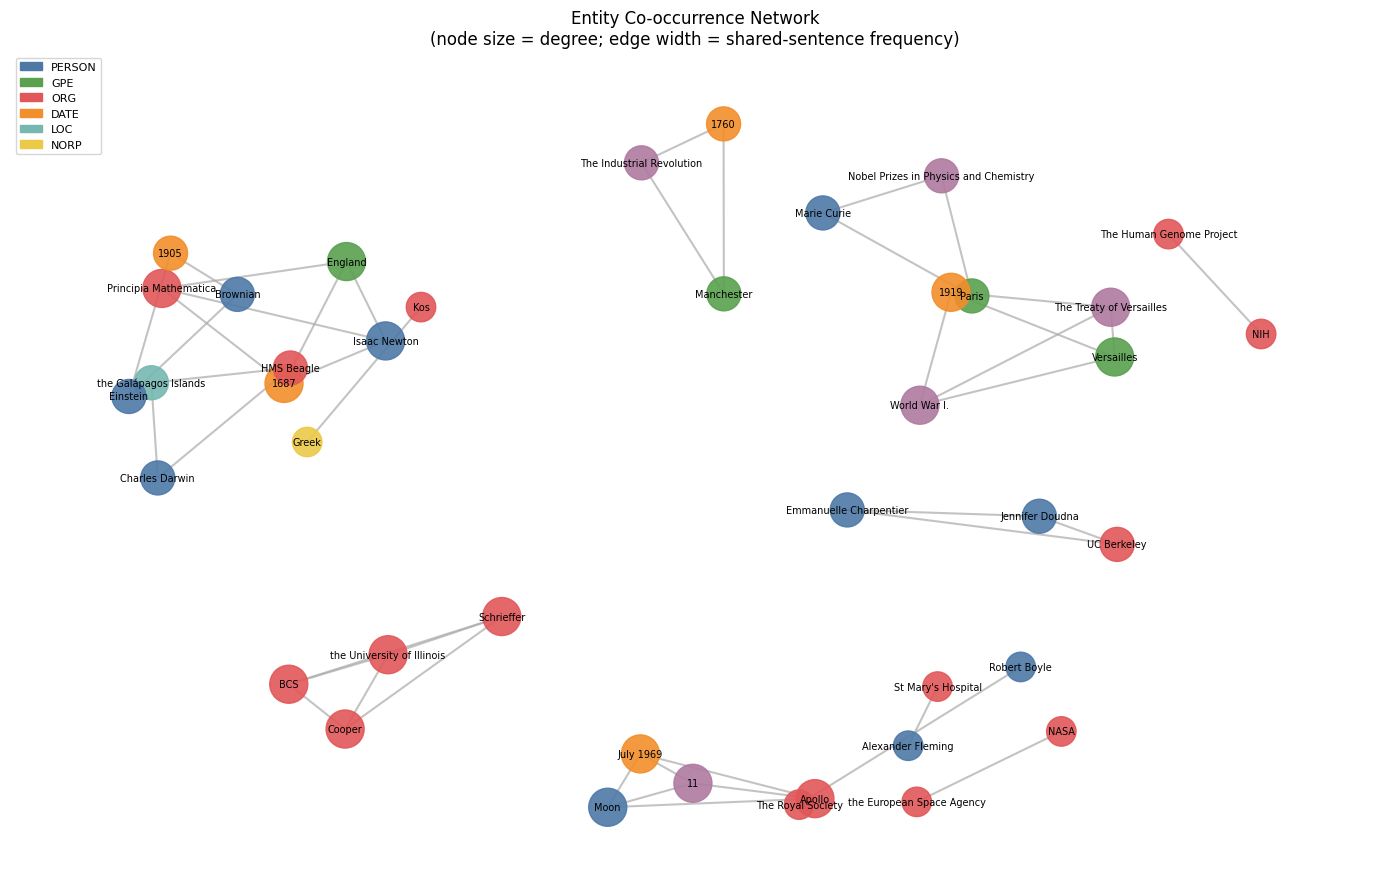

Graph: 41 nodes, 44 edges
Top hub entities: [('England', 3), ('Isaac Newton', 3), ('1687', 3), ('Principia Mathematica', 3), ('Moon', 3)]


In [33]:
G = nx.Graph()
for sentence in history_science_sentences:
    doc = nlp(sentence)
    ents_in_sent = list({ent.text for ent in doc.ents})   
    for a, b in itertools.combinations(ents_in_sent, 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

G.remove_nodes_from(list(nx.isolates(G)))

pos = nx.spring_layout(G, seed=42, k=0.6)
degrees = dict(G.degree())
node_sizes  = [300 + 150 * degrees[n] for n in G.nodes()]
edge_widths = [G[u][v]["weight"] * 1.5 for u, v in G.edges()]

label_colors = {
    "PERSON": "#4e79a7", "GPE": "#59a14f", "ORG": "#e15759",
    "DATE": "#f28e2b", "LOC": "#76b7b2", "NORP": "#edc948",
}
node_colors = []
for node in G.nodes():
    lbl = next((e.label_ for s in history_science_sentences
                for e in nlp(s).ents if e.text == node), "OTHER")
    node_colors.append(label_colors.get(lbl, "#b07aa1"))

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="#aaaaaa", alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="black")
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in label_colors.items()]
plt.legend(handles=legend_patches, loc="upper left", fontsize=8)
plt.title("Entity Co-occurrence Network\n(node size = degree; edge width = shared-sentence frequency)")
plt.axis("off"); plt.tight_layout(); plt.show()

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
top_hubs = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top hub entities:", top_hubs)


## Section 7 · Entity Timeline - Tracking Discourse Prominence

Beyond co-occurrence, **when** an entity first appears and how often it recurs across a document reveals its **discourse prominence** - a property tied to theories of **referential accessibility** and the **given-new** distinction in text comprehension (Gernsbacher, 1990). Entities introduced early and re-mentioned often become **highly accessible** in the discourse model.

We plot a **Gantt-style timeline** showing each unique entity's first and last mention position, coloured by semantic type.


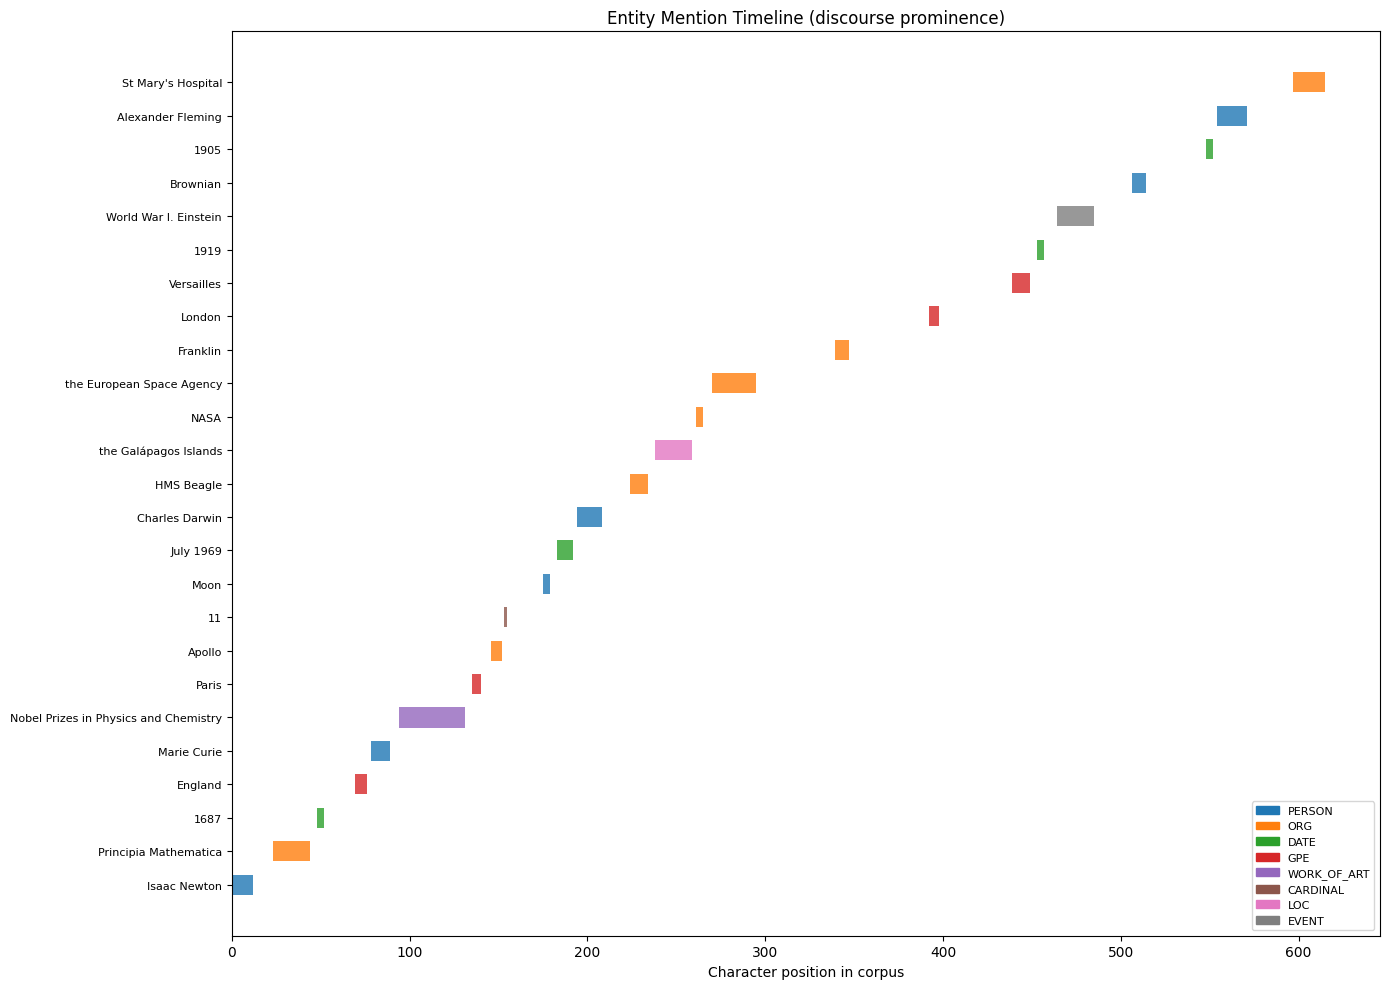

In [34]:
full_text = " ".join(history_science_sentences)
doc_full  = nlp(full_text)

timeline_rows = []
seen_first = {}
for ent in doc_full.ents:
    key = (ent.text.strip(), ent.label_)
    if key not in seen_first:
        seen_first[key] = ent.start_char
    timeline_rows.append({
        "entity": ent.text.strip(),
        "label": ent.label_,
        "start": ent.start_char,
        "end": ent.end_char,
        "first_mention": seen_first[key],
    })

tl_df = pd.DataFrame(timeline_rows).drop_duplicates(subset=["entity","start"])
tl_df = tl_df.sort_values("first_mention").reset_index(drop=True)

top_ents = tl_df["entity"].value_counts().head(25).index
tl_top   = tl_df[tl_df["entity"].isin(top_ents)]

fig, ax = plt.subplots(figsize=(14, max(6, len(top_ents) * 0.4)))
type_color = {lbl: plt.cm.tab10(i) for i, lbl in enumerate(tl_top["label"].unique())}

y_positions = {ent: i for i, ent in enumerate(tl_top["entity"].unique())}
for _, row in tl_top.iterrows():
    y = y_positions[row["entity"]]
    ax.barh(y, row["end"] - row["start"], left=row["start"], height=0.6,
            color=type_color.get(row["label"], "grey"), alpha=0.8)

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()), fontsize=8)
ax.set_xlabel("Character position in corpus")
ax.set_title("Entity Mention Timeline (discourse prominence)")
patches = [mpatches.Patch(color=c, label=l) for l, c in type_color.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()
